# Fase 4 — Análisis Exploratorio de Datos (EDA)

Proyecto: Detección temprana de pérdida de paridad en stablecoins (Binance)

Este notebook lee los datos limpios de la zona `processed` (Parquet, particionado por
símbolo/año/mes) generados en la Fase 3 (`src/quality.py`), y explora:

1. Serie de precios de USDCUSDT (y BUSDUSDT donde se usó como proxy) con los 3 eventos marcados
2. Desviación de paridad (`|close - 1.0|`) en cada evento
3. Comparación de volumen en ventanas normales vs. ventanas de estrés
4. Verificación visual de los huecos de tiempo detectados en la Fase 3


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (13, 5)

RUTA_DATOS = Path("../data/klines_clean")


## 1. Carga de datos

In [2]:
df = pd.read_parquet(RUTA_DATOS)
df = df.sort_values(["simbolo", "open_time"]).reset_index(drop=True)

print(f"Total de filas: {len(df):,}")
print(f"Símbolos: {sorted(df['simbolo'].unique())}")
print(f"Rango de fechas: {df['open_time_ts'].min()} a {df['open_time_ts'].max()}")
df.head()


Total de filas: 48,271
Símbolos: ['BTCUSDC', 'BTCUSDT', 'BUSDUSDT', 'USDCUSDT']
Rango de fechas: 2022-01-01 00:00:00 a 2023-12-31 23:00:00


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,ignore,fuente_paridad,open_time_ts,close_time_ts,simbolo,anio,mes
0,1640995200000,46216.40,46729.27,46216.40,46653.11,74.20598,1640998799999,3.455887e+06,1323,23.74160,1.104050e+06,0,BTCUSDC,2022-01-01 00:00:00,2022-01-01 00:59:59.999,BTCUSDC,2021,12
1,1640998800000,46660.14,46939.05,46573.56,46776.51,132.29666,1641002399999,6.170392e+06,2027,14.66678,6.856883e+05,0,BTCUSDC,2022-01-01 01:00:00,2022-01-01 01:59:59.999,BTCUSDC,2021,12
2,1641002400000,46783.73,46929.10,46734.29,46816.42,8.24562,1641005999999,3.861785e+05,364,3.93899,1.844868e+05,0,BTCUSDC,2022-01-01 02:00:00,2022-01-01 02:59:59.999,BTCUSDC,2021,12
3,1641006000000,46823.42,46902.40,46759.53,46811.54,19.78472,1641009599999,9.268231e+05,575,9.89035,4.633100e+05,0,BTCUSDC,2022-01-01 03:00:00,2022-01-01 03:59:59.999,BTCUSDC,2021,12
4,1641009600000,46806.32,46871.12,46628.12,46717.61,23.67957,1641013199999,1.106381e+06,712,12.45310,5.816985e+05,0,BTCUSDC,2022-01-01 04:00:00,2022-01-01 04:59:59.999,BTCUSDC,2021,12


## 2. Definición de los eventos ancla

Ventanas de los tres eventos históricos que documenta el proyecto (con margen de contexto).

In [3]:
EVENTOS = {
    "Terra/UST (may-2022)": ("2022-05-07", "2022-05-17"),
    "FTX (nov-2022)": ("2022-11-05", "2022-11-15"),
    "SVB/USDC (mar-2023)": ("2023-03-08", "2023-03-18"),
}

for nombre, (inicio, fin) in EVENTOS.items():
    print(f"{nombre}: {inicio} a {fin}")


Terra/UST (may-2022): 2022-05-07 a 2022-05-17
FTX (nov-2022): 2022-11-05 a 2022-11-15
SVB/USDC (mar-2023): 2023-03-08 a 2023-03-18


## 3. Serie de precio de paridad: USDCUSDT + proxy BUSDUSDT

Se construye una única serie de "precio de paridad" que usa USDCUSDT donde hay dato,
y BUSDUSDT (columna `fuente_paridad`) donde se aplicó el proxy — tal como se decidió
en `docs/decisiones_abiertas.md`.

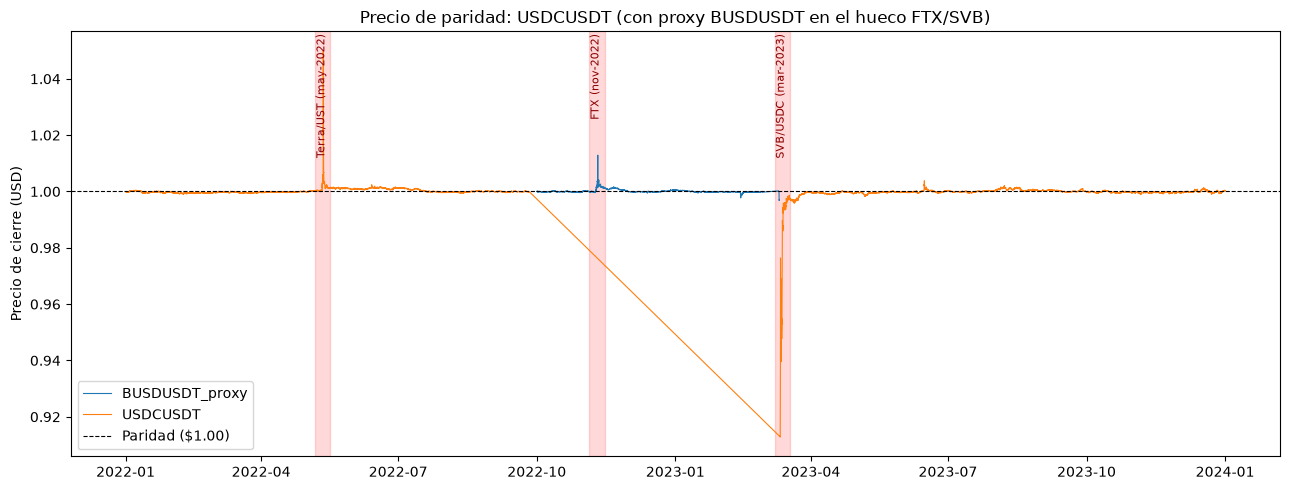

In [4]:
serie_paridad = df[df["simbolo"].isin(["USDCUSDT", "BUSDUSDT"])].copy()
serie_paridad = serie_paridad.sort_values("open_time_ts")

fig, ax = plt.subplots()
for fuente, grupo in serie_paridad.groupby("fuente_paridad"):
    ax.plot(grupo["open_time_ts"], grupo["close"], label=fuente, linewidth=0.8)

for nombre, (inicio, fin) in EVENTOS.items():
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), color="red", alpha=0.15)
    ax.text(pd.Timestamp(inicio), ax.get_ylim()[1] * 0.999, nombre,
            rotation=90, va="top", fontsize=8, color="darkred")

ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Paridad ($1.00)")
ax.set_title("Precio de paridad: USDCUSDT (con proxy BUSDUSDT en el hueco FTX/SVB)")
ax.set_ylabel("Precio de cierre (USD)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("../informe/fig_serie_paridad.png", dpi=150)
plt.show()


## 4. Desviación de paridad por evento

`desviacion = |close - 1.0|`. Se calcula el máximo y el promedio dentro de cada
ventana de evento, sobre la serie combinada USDCUSDT/BUSDUSDT.

In [5]:
serie_paridad["desviacion"] = (serie_paridad["close"] - 1.0).abs()

resumen_eventos = []
for nombre, (inicio, fin) in EVENTOS.items():
    ventana = serie_paridad[
        (serie_paridad["open_time_ts"] >= inicio) & (serie_paridad["open_time_ts"] <= fin)
    ]
    resumen_eventos.append({
        "evento": nombre,
        "filas": len(ventana),
        "desviacion_maxima": ventana["desviacion"].max(),
        "desviacion_promedio": ventana["desviacion"].mean(),
        "precio_minimo": ventana["close"].min(),
    })

resumen_eventos_df = pd.DataFrame(resumen_eventos)
resumen_eventos_df


,evento,filas,desviacion_maxima,desviacion_promedio,precio_minimo
0,Terra/UST (may-2022),241,0.0500,0.001885,0.9999
1,FTX (nov-2022),241,0.0129,0.001266,0.9996
2,SVB/USDC (mar-2023),179,0.0872,0.012330,0.9128


## 5. Volumen de trading: normal vs. estrés

Se compara el volumen promedio de USDCUSDT en periodos "normales" (fuera de las
ventanas de evento) contra el volumen dentro de cada ventana de evento.

Volumen promedio (periodo normal): 10,863,598
Volumen promedio (ventanas de evento): 37,819,265
Razón estrés/normal: 3.48x


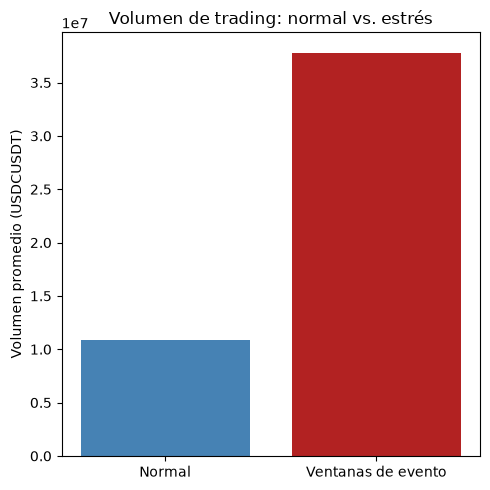

In [6]:
usdc = df[df["simbolo"] == "USDCUSDT"].copy()

mascara_evento = pd.Series(False, index=usdc.index)
for inicio, fin in EVENTOS.values():
    mascara_evento |= (usdc["open_time_ts"] >= inicio) & (usdc["open_time_ts"] <= fin)

volumen_normal = usdc.loc[~mascara_evento, "volume"].mean()
volumen_estres = usdc.loc[mascara_evento, "volume"].mean()

print(f"Volumen promedio (periodo normal): {volumen_normal:,.0f}")
print(f"Volumen promedio (ventanas de evento): {volumen_estres:,.0f}")
print(f"Razón estrés/normal: {volumen_estres / volumen_normal:.2f}x")

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Normal", "Ventanas de evento"], [volumen_normal, volumen_estres],
       color=["steelblue", "firebrick"])
ax.set_ylabel("Volumen promedio (USDCUSDT)")
ax.set_title("Volumen de trading: normal vs. estrés")
plt.tight_layout()
plt.savefig("../informe/fig_volumen_comparacion.png", dpi=150)
plt.show()


## 6. Verificación visual de los huecos de tiempo (Fase 3)

La Fase 3 detectó 6 huecos de tiempo. Se grafica la diferencia entre timestamps
consecutivos por símbolo para confirmar visualmente dónde caen.

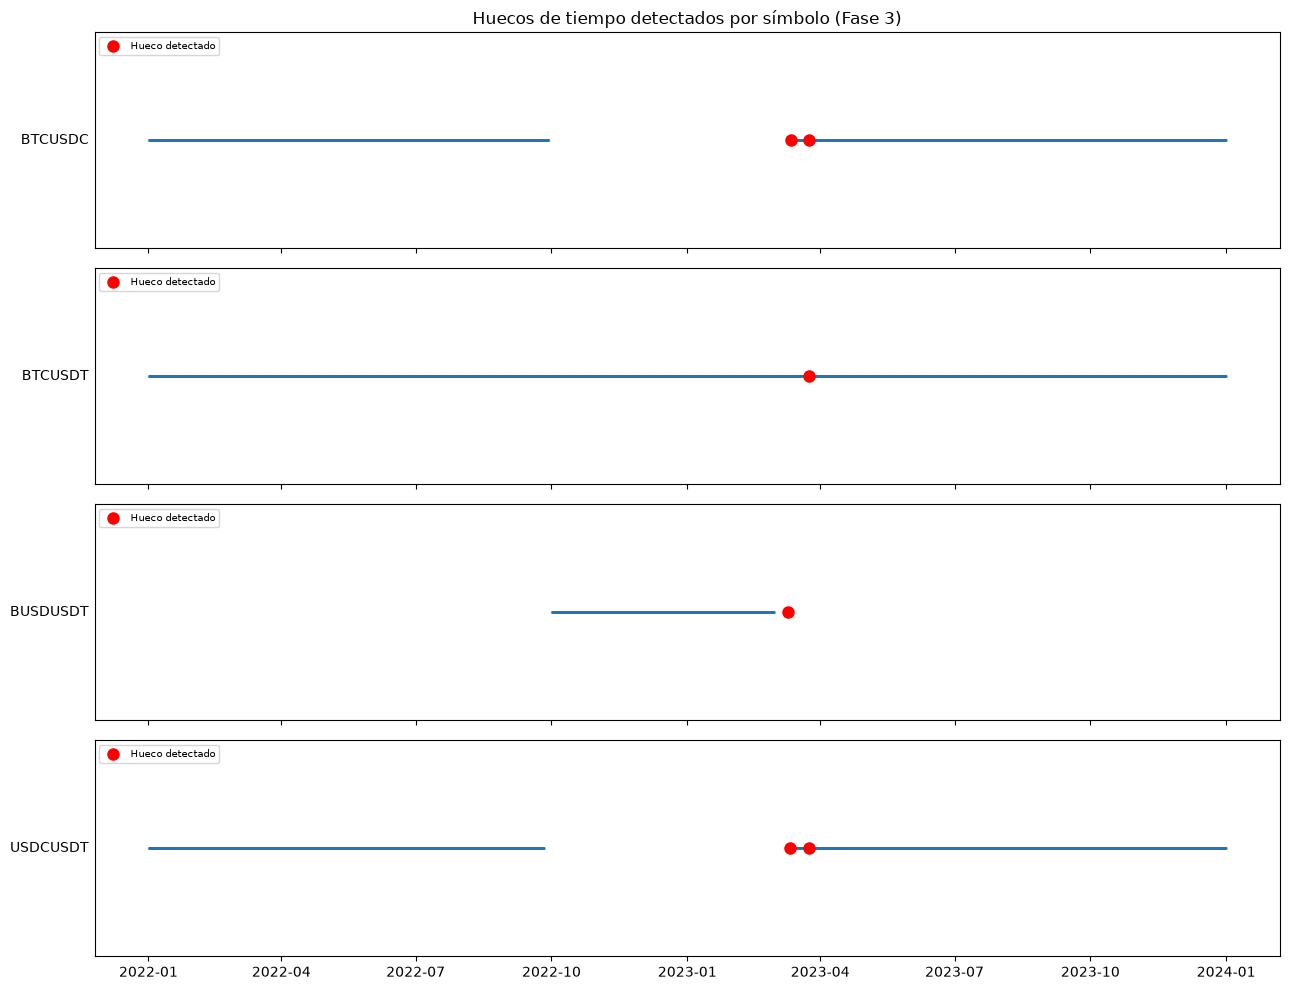

In [7]:
INTERVALO_ESPERADO = pd.Timedelta(hours=1)

fig, axes = plt.subplots(len(df["simbolo"].unique()), 1, figsize=(13, 10), sharex=True)

for ax, (simbolo, grupo) in zip(axes, df.groupby("simbolo")):
    grupo = grupo.sort_values("open_time_ts")
    gaps = grupo["open_time_ts"].diff()
    huecos = grupo[gaps != INTERVALO_ESPERADO].iloc[1:]

    ax.plot(grupo["open_time_ts"], [1] * len(grupo), "|", markersize=2, alpha=0.3)
    if len(huecos) > 0:
        ax.plot(huecos["open_time_ts"], [1] * len(huecos), "ro", markersize=8, label="Hueco detectado")
    ax.set_ylabel(simbolo, rotation=0, ha="right", va="center")
    ax.set_yticks([])
    ax.legend(loc="upper left", fontsize=7)

axes[0].set_title("Huecos de tiempo detectados por símbolo (Fase 3)")
plt.tight_layout()
plt.savefig("../informe/fig_huecos_tiempo.png", dpi=150)
plt.show()


## 7. Resumen para el informe

Celdas de arriba generan 3 figuras guardadas en `informe/`:
- `fig_serie_paridad.png`
- `fig_volumen_comparacion.png`
- `fig_huecos_tiempo.png`

Y la tabla `resumen_eventos_df` con la desviación máxima/promedio por evento,
lista para copiar a la sección de análisis del informe.